In [1]:
# Adjust the working directly to import packages using the root package
import sys
import os
notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/slt-examples


In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn_ext.mixture import BinomialMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
from plot import visualize_joint_confidence_regions
import seaborn as sns
from matplotlib.lines import Line2D
import math

default_palette = 'tab10'
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


In [3]:
dgps_file = Path("./binomix/meta.csv")
if dgps_file.exists(): # check if this data has already been generated
    print(f"File {dgps_file} exists, skipping experiments meta!.")
else:
    if dgps_file.parent: # create parents dir if not already
        dgps_file.parent.mkdir(parents=True, exist_ok=True)
        
    total_experiments = 3
    n_trials=100 # number of dna sites checked
    obs_count = 1000 # maximum number of observations to generate, this will be partitioned to study small sample size effects
    dgps_raw = {
        "dsid"  : [str(i) for i in range(total_experiments)],
        "n_trials" : np.ones(total_experiments).astype(int)*n_trials, # how many tumors are in the study
        "rho1" : np.array([0.7, 0.7, 1]), # probability of selecting a person with MSI1 tumor
        "p1" : np.array([0.3, 0.3, 0.3]), # probability of per site mutation if MSI1 tumor
        "p2" : np.array([0.2, 0.3, 0.2]), # probability of per site mutation if MSI2 tumor
        "obs_count": np.ones(total_experiments).astype(int)*obs_count,
    }
    dgps_raw["rho2"] = 1-dgps_raw["rho1"]
    pd.DataFrame(dgps_raw).set_index("dsid").to_csv(dgps_file)
    print(f"File {dgps_file} created!.")

dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

File binomix/meta.csv created!.


,dsid,n_trials,rho1,p1,p2,obs_count,rho2
0,0,100,0.7,0.3,0.2,1000,0.3
1,1,100,0.7,0.3,0.3,1000,0.3
2,2,100,1.0,0.3,0.2,1000,0.0


In [4]:
obs_file = Path("./binomix/obs.csv") # where we are going to store observations
if obs_file.exists(): # check if this data has already been generated
    print(f"File {obs_file} exists, skipping random samples creation!.")
else:
    if obs_file.parent: # create parents dir if not already
        obs_file.parent.mkdir(parents=True, exist_ok=True)
                
    obs_count = dgps["obs_count"].unique().item()
    datasets = dgps["dsid"].unique()
    obs = {}
    for dsid in datasets:
        dgp = dgps.query(f"dsid=={dsid}")
        n_trials = dgp["n_trials"].astype(int).item()
        weights = dgp[["rho1", "rho2"]].iloc[0].tolist()
        probs = dgp[["p1", "p2"]].iloc[0].tolist()
        dd = BinomialMixture(n_components=2, weights_init=weights, probs_init=probs, n_trials=n_trials)
        samples = dd.sample(n_samples=obs_count)
        obs["n_trials"] = np.ones(obs_count, dtype=int)*n_trials
        obs[f"x_{dsid}"] = samples[0].astype(int).tolist()
    
    
    obs_df = pd.DataFrame(obs)
    obs_df.to_csv(obs_file)
    print(f"File {obs_file} created!.")

obs_df=pd.read_csv(obs_file, index_col=0).reset_index()
obs_df.head()

File binomix/obs.csv created!.


,index,n_trials,x_0,x_1,x_2
0,0,100,24,33,32
1,1,100,19,41,24
2,2,100,27,25,33
3,3,100,17,27,26
4,4,100,23,26,27


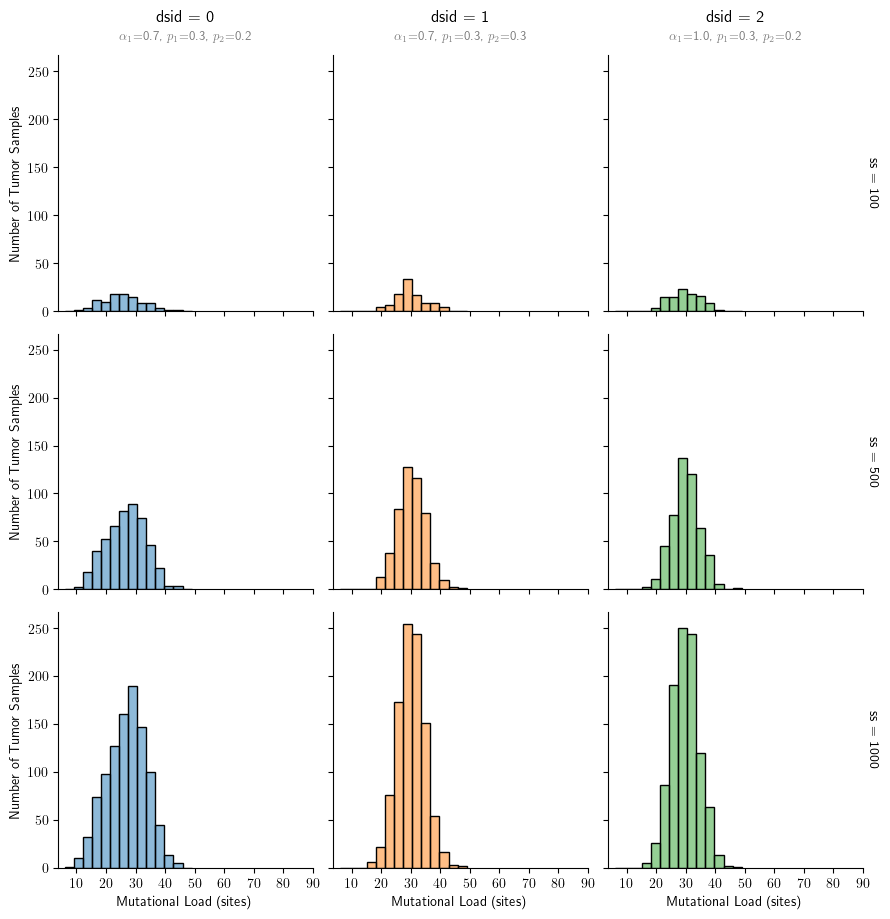

In [6]:
n_trials = dgps["n_trials"].unique()[0]
datasets = dgps["dsid"].unique()
obs_count = dgps["obs_count"].unique().item()
ss_steps = [np.ceil(x).astype(int) for x in [obs_count*.1, obs_count*.5, obs_count]] # sample sizes to use for the analysis to show the effect of different samples

# plot the data sets as different sample sizes
# we need to structure the plotting data for different sample sizes (keeping in mind that we are not regenerating the sample in each sample size)
plotdata = {"x": [], "ss": [], "dsid": []} # raw data to initialize the plotting dataframe

for dsid in datasets:
    dgp = dgps.query(f'dsid == {dsid}')
    for ss in ss_steps:
        x = obs_df[f"x_{dsid}"].iloc[0:ss]
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["ss"]=np.append(plotdata["ss"], (np.ones(ss)*ss).astype(int))
        # plotdata["n_trials"]=np.append(plotdata["n_trials"], dgp["n_trials"].iloc[0])
        plotdata["dsid"]=np.append(plotdata["dsid"], (np.ones(ss)*dsid).astype(int))


plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "ss": int, "dsid": int})
g=sns.displot(plotdf, 
              x="x", col="dsid", row="ss", bins=n_trials, hue="dsid",
    binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": True}, legend=False, palette=default_palette
)
g.set_axis_labels("Mutational Load (sites)", "Number of Tumor Samples")

subtitles={}
for i in range(len(datasets)):
    ditem = dgps.iloc[i,:]
    subtitles[str(i)]=f'$\\alpha_1$={ditem["rho1"].item()}, $p_1$={ditem["p1"].item()}, $p_2$={ditem["p2"].item()}'

# Only modify the top row of subplots (these have the column titles)
for ax in g.axes[0, :]:  # [0, :] means first row, all columns
    title = ax.get_title()
    if ' = ' in title:
        col_value = title.split(' = ')[1]
        if col_value in subtitles:
            # ax.set_title(f'{column_labels[col_value]}')
            # Set the main title
            ax.set_title(title, pad=25)
            
            # Add subtitle as text annotation
            ax.text(0.5, 1.05, subtitles[col_value], 
                   transform=ax.transAxes, 
                   ha='center', va='bottom',
                   fontsize=9, style='italic', color='gray')

for ax in g.axes.flat:
    ax.set_xticks(list(range(10, 100, 10)))
plt.savefig('binomix/dataset.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
import random
# compute the confidence region using gaussian approximation
estimates={"dsid": [], "n": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "confidence_regions": []}
for dsid in range(datasets_count):
    for n in tqdm(n_steps, desc=f"n_steps"):
        file = Path(obs_pathstr.format(dsid=dsid, n=n))
        Xs = pd.read_csv(file)
        estimate, model =compute_mle(x_obs=Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["dsid"].append(dsid)
        estimates["n"].append(n)
        estimates["rho1"].append(estimate["rho1"])
        estimates["rho2"].append(estimate["rho2"])
        estimates["p1"].append(estimate["p1"])
        estimates["p2"].append(estimate["p2"])
        confidence_region_data = model.compute_fisher_confidence_region(Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["cov_matrix"].append(confidence_region_data["cov_matrix"])
        estimates["chi2_critical"].append(confidence_region_data["chi2_critical"])
        estimates["confidence_level"].append(confidence_region_data["confidence_level"])
        estimates["standard_errors"].append(confidence_region_data["standard_errors"])

estimates

n_steps:   0%|          | 0/3 [00:00<?, ?it/s]

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your mle_df dataframe
g = sns.pairplot(
    mle_df[["n", "rho1", "p1", "p2"]].rename(columns={
        'n': 'n',
        'rho1': '$\\rho_1$', 
        'p1': '$p_1$', 
        'p2': '$p_2$'
    }), 
    hue='n',
    hue_order=[1000, 500, 100],  # explicit order
    height=4,
    aspect=1,
    diag_kind="hist",
    plot_kws={
        'alpha': 0.5,
        's': 5,
        'marker': '.',
        'linewidth': 0,  # removes edge lines for cleaner look
    },
    diag_kws={
        'alpha': 0.7,
        'bins': 30,  # if using histograms on diagonal
    }
)

# Set axis labels with LaTeX formatting
# g.set_axis_labels('$p_1$', '$\\rho_1$')

plt.show()

KeyError: "['n'] not in index"

In [ ]:
def resample_and_fit(X, random_state, n_samples, max_iter=10**3, tol=10**3, n_init=1):
    try:
        X_boot = resample(X, random_state=random_state, n_samples=n_samples)
        bmm_boot = BinomialMixture(n_components=2, 
                                   tol=tol, 
                                   max_iter=max_iter,
                                   n_init=n_init)
        
        bmm_boot.fit(X_boot)
        
        if not bmm_boot.converged_:
            raise Error(f"Iteration {i} didn't converge!")

        bmm_boot._enforce_ordering() 
    
        mle = {
            "p1": bmm_boot.probs_[0],
            "p2": bmm_boot.probs_[1], 
            "rho1": bmm_boot.weights_[0],
            "rho2": bmm_boot.weights_[1],
            'iteration': i
        }

    except Exception as e:
        print(f"Error in bootstrap iteration {i}: {e}")
        return None

In [32]:
##### Set the known variances
n_incr = int(n_samples*1/5)
#partition the total samples into 1/10 increments to show case the impact of number of trials on estimates
n_steps = np.arange(n_incr, n_samples+n_incr, n_incr)
estimates_ts = {}

for e in tqdm(range(total_experiments), desc=f"experiment "):
    w0 = dgp_df.loc[f"{e}"]
    x_obs=(data[[f'{e}_x', f"{e}_n"]]).values
    for i in tqdm(range(len(n_steps)), desc=f"trials "):
        nn = n_steps[i]
        estimates = compute_mle(x_obs=x_obs[:nn],
                                n_bootstrap=10000,
                                max_iter=10**3,
                                tol=10e-3)

        if f"dataset_{e}" not in estimates_ts:
            estimates_ts[f"dataset_{e}"] = { "n":[], "p1": [], "p2": [], "rho1": [], "rho2": []}

        ds = estimates_ts.get(f"dataset_{e}")
        ds["n"].append(nn)
        for pname in ["p1", "p2", "rho1", "rho2"]:
            ss = estimates[pname]["bootstraps"]
            ci_upper = estimates[pname]["ci_upper"]
            ci_lower = estimates[pname]["ci_lower"]
            
            ds[pname].append({
                "mle": estimates[pname]["mle"],
                "bootstraps": estimates[pname]["bootstraps"],
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "boot_min": np.min(estimates[pname]["bootstraps"]),
                "boot_max": np.max(estimates[pname]["bootstraps"])
            })

experiment :   0%|          | 0/4 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

trials :   0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 0.98, 'Bootstrap confidence regions, n=250')

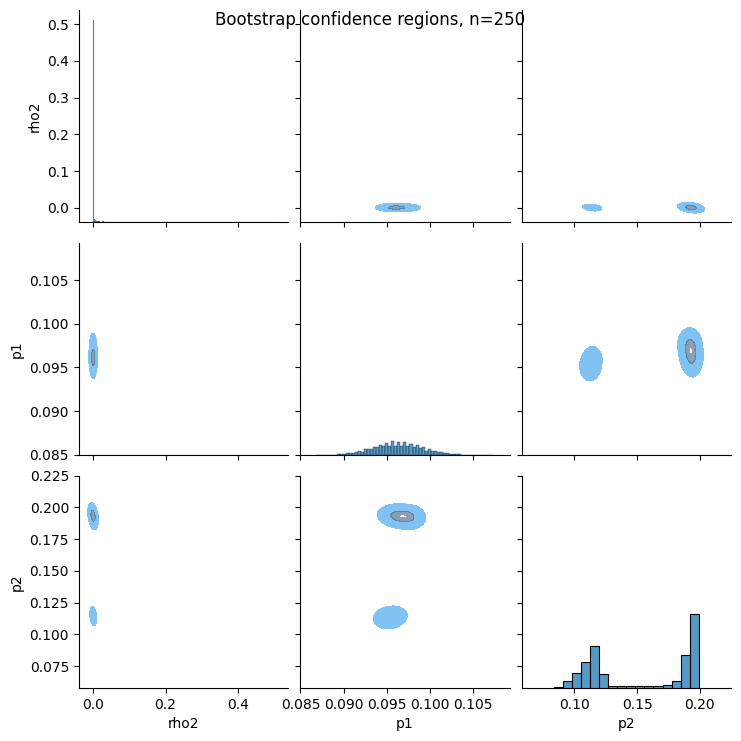

In [37]:
# Create DataFrame
dsid = f"dataset_2"
w_true = {
    # "rho1": dgp_df.loc["1", ["rho1"]],
    "rho2": dgp_df.loc["1", ["rho2"]],
    "p1": dgp_df.loc["1", ["p1"]],
    "p2": dgp_df.loc["1", ["p2"]]
}

# for i in range(len(estimates_ts[dsid]["rho1"])):
crdata = pd.DataFrame({
    # 'rho1': estimates_ts[dsid]["rho1"][4]["bootstraps"],
    'rho2': estimates_ts[dsid]["rho2"][1]["bootstraps"], 
    'p1': estimates_ts[dsid]["p1"][1]["bootstraps"],
    'p2': estimates_ts[dsid]["p2"][1]["bootstraps"]
})

# fig, axes = visualize_joint_confidence_regions(crdata, 
#                                           true_params=w_true,
#                                           methods=['kde', 'ellipse']
#                                               )  # Focus on key methods
    
# Create pairplot
g = sns.pairplot(crdata,
                 # corner=True,
                 kind="kde",
                 diag_kind='hist',
                 plot_kws={'levels': [0.68, 0.95, 0.995], 
                           'alpha': 0.6,
                           'fill': True} # Filled contours
                )

# g.set(xlim=(0, 1), ylim=(0, 1))
# Customize the plot
g.fig.suptitle(f'Bootstrap confidence regions, n={estimates_ts[dsid]["n"][i]}')
    
    # print(estimates_ts[dsid]["rho2"][1]["ci_lower"])
    # print(estimates_ts[dsid]["rho2"][1]["ci_upper"])

In [31]:
# Plot the results
def plot_percentile_results(data, pname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    global_min = None
    global_max = None
    for i, dataset in enumerate([f'dataset_{j}' for j in range(0, total_experiments)]):
        ax = axes[i]

        mle = [x["mle"] for x in data[dataset][pname]]
        ci_lower = [x["ci_lower"] for x in data[dataset][pname]]
        ci_upper = [x["ci_upper"] for x in data[dataset][pname]]

        if not global_min:
            global_min = np.min(ci_lower)
        else:
            possible_min = np.min(ci_lower)
            global_min = global_min if global_min < possible_min else possible_min
            
        if not global_max:
            global_max = np.max(ci_upper)
        else:
            possible_max = np.max(ci_upper)
            global_max = global_max if global_max > possible_max else possible_max
        
        x = data[dataset]['n']
        y = mle
        ci_lower = ci_lower
        ci_upper = ci_upper
        
        # Plot estimate
        ax.plot(x, y, 'o-', color='gray', markersize=4)
        
        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color='pink')
        truth = (dgp_df.loc[f"{i}", [pname]]).item()
        # print(f"dataset={dataset}, truth={truth:0.3f}, mle={data[dataset]['mle'][pname]}")
        ax.axhline(y=truth, color='blue', linestyle='-', linewidth=2, alpha=0.8)
        ax.set_title(f'Dataset {i+1} - 95th Percentile')
        ax.set_xlabel('Sample Size')
        ax.set_ylabel(f'{pname} estimate')
        ax.grid(True, alpha=0.3)

    padding = (global_max-global_min)*0.1
    for ax in axes:
        ax.set_ylim(global_min-padding, global_max+padding)
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_percentile_results(data=estimates_ts, pname="p1")

In [ ]:
plot_percentile_results(estimates_ts, pname="p2")

In [ ]:
plot_percentile_results(estimates_ts, pname="rho2")